# MODELADO

In [2]:
import pandas as pd #Importar librería pandas
import numpy as np #Importar librería numpy
import os #Importar módulo sistema

FILE_INPUT = "../ETL/datalake/gold/clean/dataset_master_gold.parquet" #Definir ruta origen relativa
FILE_OUTPUT = "data/dataset_modelado_churn.parquet" #Definir ruta salida parquet
FILE_OUTPUT_CSV = "data/dataset_modelado_churn.csv" #Definir ruta salida csv

def aplicar_ingenieria_caracteristicas(): #Definir función principal
    print("Iniciando Ingeniería de Características (Feature Engineering)...") #Imprimir inicio proceso
    
    try: #Iniciar bloque prueba
        df = pd.read_parquet(FILE_INPUT) #Cargar archivo parquet
        print("[EXITO] Archivo Parquet cargado correctamente.") #Imprimir éxito
    except FileNotFoundError: #Capturar error archivo
        print(f"[ERROR] No se encontró el archivo en: {FILE_INPUT}") #Imprimir error ruta
        return None #Devolver nulo
        
    print("   Filtrando clientes ACTIVOS y BAJAS...") #Imprimir estado proceso
    #Solo nos interesan estos dos estados para predecir la cancelación
    df = df[df['ESTATUS_x'].isin(['ACTIVO', 'BAJA'])].copy() #Filtrar base de datos
    
    #Limpiar modelos nulos antes de agrupar para evitar errores
    df['ONT_MODEL'] = df['ONT_MODEL'].replace(['nan', 'NaN', 'NAN'], 'DESCONOCIDO') #Reemplazar falsos nulos
    df['ONT_MODEL'] = df['ONT_MODEL'].fillna('DESCONOCIDO') #Imputar nulos reales
    
    print("   Agrupando historial por cliente único (CONTRATO)...") #Imprimir estado proceso
    
    #Crear diccionario con las reglas matemáticas para cada columna al agrupar
    agregaciones = { #Definir diccionario agregaciones
        'MOTIVO_PEDIDO': 'count', #Contar total reportes por cliente
        'RX_AVG': 'mean', #Calcular promedio histórico de potencia
        'DIAS_ATENCION': 'mean', #Calcular promedio de días en resolverle
        'ONT_MODEL': lambda x: x.mode()[0] if not x.mode().empty else 'DESCONOCIDO', #Obtener módem más usado
        'ZONA': lambda x: x.mode()[0] if not x.mode().empty else 'DESCONOCIDO', #Obtener zona principal
        'ESTATUS_x': 'last' #Obtener estado final actual del cliente
    } #Cerrar diccionario
    
    #Ejecutar agrupación
    df_agrupado = df.groupby('CONTRATO').agg(agregaciones).reset_index() #Agrupar y aplicar cálculos
    
    print("   Creando variable objetivo binaria (TARGET_CHURN)...") #Imprimir estado proceso
    
    df_agrupado.rename(columns={ #Renombrar columnas
        'MOTIVO_PEDIDO': 'TOTAL_FALLAS', #Asignar nuevo nombre
        'RX_AVG': 'RX_AVG_PROMEDIO', #Asignar nuevo nombre
        'DIAS_ATENCION': 'DIAS_ATENCION_PROMEDIO' #Asignar nuevo nombre
    }, inplace=True) #Aplicar cambios directamente
    
    #Convertir texto a número binario para el modelo de Machine Learning (1=BAJA, 0=ACTIVO)
    df_agrupado['TARGET_CHURN'] = np.where(df_agrupado['ESTATUS_x'] == 'BAJA', 1, 0) #Crear variable binaria
    df_agrupado.drop(columns=['ESTATUS_x'], inplace=True) #Eliminar columna texto original
    
    print("   Imputando nulos generados en los promedios...") #Imprimir estado proceso
    
    #Si un cliente nunca tuvo medición de potencia, se le asigna la mediana global
    mediana_rx = df_agrupado['RX_AVG_PROMEDIO'].median() #Calcular mediana potencia
    df_agrupado['RX_AVG_PROMEDIO'] = df_agrupado['RX_AVG_PROMEDIO'].fillna(mediana_rx) #Imputar mediana a nulos
    
    mediana_dias = df_agrupado['DIAS_ATENCION_PROMEDIO'].median() #Calcular mediana dias
    df_agrupado['DIAS_ATENCION_PROMEDIO'] = df_agrupado['DIAS_ATENCION_PROMEDIO'].fillna(mediana_dias) #Imputar mediana a nulos
    
    print(f"   Guardando dataset preparado en {FILE_OUTPUT}...") #Imprimir estado guardado
    df_agrupado.to_parquet(FILE_OUTPUT, index=False) #Exportar a parquet final
    df_agrupado.to_csv(FILE_OUTPUT_CSV, index=False, encoding='utf-8-sig') #Exportar a csv final
    
    print("[EXITO] Ingeniería de Características finalizada.") #Imprimir éxito
    
    print("\n--- MUESTRA DEL DATASET LISTO PARA MODELADO ---") #Imprimir separador
    print(df_agrupado.head()) #Mostrar primeros 5 registros
    
    return df_agrupado #Devolver dataframe en memoria

if __name__ == "__main__": #Verificar ejecución directa
    df_modelado = aplicar_ingenieria_caracteristicas() #Ejecutar función principal

Iniciando Ingeniería de Características (Feature Engineering)...
[EXITO] Archivo Parquet cargado correctamente.
   Filtrando clientes ACTIVOS y BAJAS...
   Agrupando historial por cliente único (CONTRATO)...
   Creando variable objetivo binaria (TARGET_CHURN)...
   Imputando nulos generados en los promedios...
   Guardando dataset preparado en data/dataset_modelado_churn.parquet...
[EXITO] Ingeniería de Características finalizada.

--- MUESTRA DEL DATASET LISTO PARA MODELADO ---
  CONTRATO  TOTAL_FALLAS  RX_AVG_PROMEDIO  DIAS_ATENCION_PROMEDIO ONT_MODEL  \
0    10023             1       -18.122341                     2.0       IGD   
1    10034             1       -26.486845                     1.0  MN-CATV2   
2    10035             1       -27.346784                     1.0  MN-WIFI2   
3    10039             1       -24.280153                     1.0  BT-213XR   
4    10049             2       -26.044325                     1.0  MN-WIFI2   

         ZONA  TARGET_CHURN  
0    PEDREG

## DATOS DE ENTRENAMIENTO Y PRUEBA

In [4]:
import pandas as pd #Importar librería pandas
from sklearn.model_selection import train_test_split #Importar función división

FILE_INPUT = "data/dataset_modelado_churn.parquet" #Definir ruta origen

def preparar_datos_entrenamiento(): #Definir función principal
    print("Iniciando preparación y división de datos (80/20)...") #Imprimir inicio proceso
    
    try: #Iniciar bloque prueba
        df = pd.read_parquet(FILE_INPUT) #Cargar archivo parquet
        print("[EXITO] Dataset de modelado cargado correctamente.") #Imprimir éxito
    except FileNotFoundError: #Capturar error archivo
        print(f"[ERROR] No se encontró el archivo: {FILE_INPUT}") #Imprimir error ruta
        return None, None, None, None #Devolver nulos
        
    print("\n   Separando variables predictoras y variable objetivo...") #Imprimir estado proceso
    
    X = df.drop(columns=['CONTRATO', 'TARGET_CHURN']) #Extraer variables independientes
    y = df['TARGET_CHURN'] #Extraer variable dependiente
    
    print("\n   Convirtiendo variables de texto a formato numérico (Dummies)...") #Imprimir estado proceso
    
    #Convertir ONT_MODEL y ZONA a columnas binarias de ceros y unos
    X_codificado = pd.get_dummies(X, columns=['ONT_MODEL', 'ZONA'], drop_first=True) #Aplicar codificacion
    
    print("\n--- DETALLE: RESULTADO DE ONE-HOT ENCODING ---") #Imprimir encabezado detalle
    print(f"Las variables de texto se transformaron en {X_codificado.shape[1]} columnas numéricas (0 y True/False).") #Imprimir explicacion
    print("Muestra de las primeras 5 filas (Mostrando las primeras 8 columnas):") #Imprimir subtitulo
    print(X_codificado.head()) #Imprimir muestra de datos transformados
    
    print("\n   Ejecutando partición 80% Entrenamiento / 20% Prueba...") #Imprimir estado proceso
    
    X_train, X_test, y_train, y_test = train_test_split(X_codificado, y, test_size=0.20, random_state=42, stratify=y) #Dividir datos
    
    print("\n[EXITO] División completada.") #Imprimir éxito final
    print("-" * 65) #Imprimir separador
    print("RESUMEN DETALLADO DE LA PARTICIÓN ESTRATIFICADA:") #Imprimir encabezado
    
    #Calcular conteos exactos para validación detallada
    total_activos = (y == 0).sum() #Contar activos totales
    total_bajas = (y == 1).sum() #Contar bajas totales
    
    train_activos = (y_train == 0).sum() #Contar activos entrenamiento
    train_bajas = (y_train == 1).sum() #Contar bajas entrenamiento
    
    test_activos = (y_test == 0).sum() #Contar activos prueba
    test_bajas = (y_test == 1).sum() #Contar bajas prueba
    
    #Impresión de los bloques con conteos exactos y porcentajes
    print(f"\n1. DATASET ORIGINAL (Total: {len(df)} clientes)") #Imprimir titulo original
    print(f"   - ACTIVOS (0): {total_activos} clientes ({(total_activos/len(df))*100:.2f}%)") #Imprimir activos original
    print(f"   - BAJAS (1):   {total_bajas} clientes ({(total_bajas/len(df))*100:.2f}%)") #Imprimir bajas original
    
    print(f"\n2. SET DE ENTRENAMIENTO - 80% (Total: {len(X_train)} clientes)") #Imprimir titulo entrenamiento
    print(f"   - ACTIVOS (0): {train_activos} clientes ({(train_activos/len(y_train))*100:.2f}%)") #Imprimir activos train
    print(f"   - BAJAS (1):   {train_bajas} clientes ({(train_bajas/len(y_train))*100:.2f}%)") #Imprimir bajas train
    
    print(f"\n3. SET DE PRUEBA - 20% (Total: {len(X_test)} clientes)") #Imprimir titulo prueba
    print(f"   - ACTIVOS (0): {test_activos} clientes ({(test_activos/len(y_test))*100:.2f}%)") #Imprimir activos test
    print(f"   - BAJAS (1):   {test_bajas} clientes ({(test_bajas/len(y_test))*100:.2f}%)") #Imprimir bajas test
    print("-" * 65) #Imprimir separador final
    
    return X_train, X_test, y_train, y_test #Retornar variables

if __name__ == "__main__": #Verificar ejecución directa
    X_entrenamiento, X_prueba, y_entrenamiento, y_prueba = preparar_datos_entrenamiento() #Ejecutar función principal

Iniciando preparación y división de datos (80/20)...
[EXITO] Dataset de modelado cargado correctamente.

   Separando variables predictoras y variable objetivo...

   Convirtiendo variables de texto a formato numérico (Dummies)...

--- DETALLE: RESULTADO DE ONE-HOT ENCODING ---
Las variables de texto se transformaron en 48 columnas numéricas (0 y True/False).
Muestra de las primeras 5 filas (Mostrando las primeras 8 columnas):
   TOTAL_FALLAS  RX_AVG_PROMEDIO  DIAS_ATENCION_PROMEDIO  ONT_MODEL_546M  \
0             1       -18.122341                     2.0           False   
1             1       -26.486845                     1.0           False   
2             1       -27.346784                     1.0           False   
3             1       -24.280153                     1.0           False   
4             2       -26.044325                     1.0           False   

   ONT_MODEL_BT-211XR  ONT_MODEL_BT-213XR  ONT_MODEL_BT-713XR  \
0               False               False      

## ENTRENAMIENTO Y EVALUACION DE LOS MODELOS

In [6]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold #Importar módulos validación
from sklearn.ensemble import RandomForestClassifier #Importar modelo random forest
from xgboost import XGBClassifier #Importar modelo xgboost
from sklearn.metrics import recall_score, f1_score, roc_auc_score #Importar métricas
from sklearn.metrics import classification_report #Asegúrate de poner esto al inicio del script con los demás imports
import joblib #Importar librería para guardar objetos en disco

def entrenar_y_evaluar_modelos(X_train, X_test, y_train, y_test): #Definir función recibiendo datos
    print("Iniciando Entrenamiento Comparativo (Random Forest vs XGBoost)...") #Imprimir inicio proceso
    
    X_train = X_train.astype(float) #Convertir entrenamiento a decimales
    X_test = X_test.astype(float) #Convertir prueba a decimales
    
    #Configurar validación cruzada para mantener proporción de cancelaciones
    cv_estratificada = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) #Definir divisiones
    
    #RANDOM FOREST
    print("\n   Entrenando Modelo 1: Random Forest (Buscando mejores hiperparámetros)...") #Imprimir estado proceso
    
    #class_weight='balanced' le da más peso a los clientes que cancelaron para compensar la minoría
    rf_base = RandomForestClassifier(class_weight='balanced', random_state=42) #Instanciar modelo base
    
    rf_parametros = { #Definir diccionario parametros
        'n_estimators': [50, 100, 200], #Probar cantidad arboles
        'max_depth': [5, 10, 15] #Probar profundidad maxima
    } #Cerrar diccionario
    
    #scoring='recall' obliga al modelo a optimizar la detección de bajas
    rf_grid = GridSearchCV(estimator=rf_base, param_grid=rf_parametros, cv=cv_estratificada, scoring='recall', n_jobs=-1) #Configurar busqueda
    rf_grid.fit(X_train, y_train) #Entrenar modelo optimizado
    rf_mejor = rf_grid.best_estimator_ #Extraer modelo ganador
    
    print(f"   [EXITO] Random Forest listo. Mejores parámetros: {rf_grid.best_params_}") #Imprimir mejores parametros
    
    #XGBOOST
    print("\n   Entrenando Modelo 2: XGBoost (Buscando mejores hiperparámetros)...") #Imprimir estado proceso
    
    #scale_pos_weight compensa matemáticamente el desbalance de clases (Total Activos / Total Bajas)
    peso_clases = (y_train == 0).sum() / (y_train == 1).sum() #Calcular proporcion desbalance
    
    xgb_base = XGBClassifier(scale_pos_weight=peso_clases, random_state=42, eval_metric='logloss') #Instanciar modelo base
    
    xgb_parametros = { #Definir diccionario parametros
        'n_estimators': [50, 100, 200], #Probar cantidad arboles
        'learning_rate': [0.01, 0.05, 0.1], #Probar tasa aprendizaje
        'max_depth': [3, 5, 7] #Probar profundidad maxima
    } #Cerrar diccionario
    
    xgb_grid = GridSearchCV(estimator=xgb_base, param_grid=xgb_parametros, cv=cv_estratificada, scoring='recall', n_jobs=-1) #Configurar busqueda
    xgb_grid.fit(X_train, y_train) #Entrenar modelo optimizado

    print("Guardando XGBoost y su estructura de columnas...") #Imprimir aviso
    joblib.dump(xgb_grid, 'modelo_xgboost_2025.pkl') #Exportar modelo entrenado a archivo físico

    columnas_entrenamiento = X_train.columns.tolist() #Extraer lista con los nombres exactos de las columnas
    joblib.dump(columnas_entrenamiento, 'columnas_entrenamiento_2025.pkl') #Exportar lista de columnas a archivo físico
    print("[EXITO] Exportación lista.") #Imprimir éxito
    
    xgb_mejor = xgb_grid.best_estimator_ #Extraer modelo ganador
    
    print(f"   [EXITO] XGBoost listo. Mejores parámetros: {xgb_grid.best_params_}") #Imprimir mejores parametros
    
    #EVALUACIÓN Y COMPARACIÓN
    print("\n" + "="*55) #Imprimir separador
    print("EVALUACIÓN DEL RENDIMIENTO EN DATOS DE PRUEBA (20%)") #Imprimir encabezado
    print("="*55) #Imprimir separador
    
    #Predicciones Random Forest
    rf_pred = rf_mejor.predict(X_test) #Predecir etiquetas discretas
    rf_prob = rf_mejor.predict_proba(X_test)[:, 1] #Predecir probabilidades continuas
    
    #Predicciones XGBoost
    xgb_pred = xgb_mejor.predict(X_test) #Predecir etiquetas discretas
    xgb_prob = xgb_mejor.predict_proba(X_test)[:, 1] #Predecir probabilidades continuas
    
    #Resultados
    print("\n--- MÉTRICAS: RANDOM FOREST ---") #Imprimir subtitulo
    print(f"Recall (Exhaustividad): {recall_score(y_test, rf_pred):.4f}") #Imprimir recall
    print(f"F1-Score:             {f1_score(y_test, rf_pred):.4f}") #Imprimir f1
    print(f"ROC-AUC:              {roc_auc_score(y_test, rf_prob):.4f}") #Imprimir auc
    
    print("\n--- MÉTRICAS: XGBOOST ---") #Imprimir subtitulo
    print(f"Recall (Exhaustividad): {recall_score(y_test, xgb_pred):.4f}") #Imprimir recall
    print(f"F1-Score:             {f1_score(y_test, xgb_pred):.4f}") #Imprimir f1
    print(f"ROC-AUC:              {roc_auc_score(y_test, xgb_prob):.4f}") #Imprimir auc
    print("\n" + "="*55) #Imprimir separador

    print("\n" + "="*55) #Imprimir separador
    print("REPORTE DE CLASIFICACIÓN DETALLADO (RANDOM FOREST)") #Imprimir encabezado
    print("="*55) #Imprimir separador
    #Imprime precisión, recall y f1 para ambas clases (0: Activo, 1: Baja)
    print(classification_report(y_test, rf_pred, target_names=['ACTIVO (0)', 'BAJA (1)'])) #Imprimir reporte RF
    
    print("\n" + "="*55) #Imprimir separador
    print("TOP 5 VARIABLES MÁS IMPORTANTES (Según Random Forest)") #Imprimir encabezado
    print("="*55) #Imprimir separador
    #Extraer y ordenar la importancia matemática que Random Forest le dio a cada columna
    importancias_rf = pd.Series(rf_mejor.feature_importances_, index=X_train.columns) #Mapear variables RF
    importancias_top_rf = importancias_rf.sort_values(ascending=False).head(5) #Filtrar top 5
    
    #Imprimir con formato de porcentaje
    for variable, peso in importancias_top_rf.items(): #Iterar sobre el top 5
        print(f"{variable}: {peso*100:.2f}% de influencia") #Imprimir resultado

    print("\n" + "="*55)
    print("REPORTE DE CLASIFICACIÓN DETALLADO (XGBOOST)")
    print("="*55)
    #Imprime precisión, recall y f1 para ambas clases (0: Activo, 1: Baja)
    print(classification_report(y_test, xgb_pred, target_names=['ACTIVO (0)', 'BAJA (1)']))
    
    print("\n" + "="*55)
    print("TOP 5 VARIABLES MÁS IMPORTANTES (Según XGBoost)")
    print("="*55)
    #Extraer y ordenar la importancia matemática que XGBoost le dio a cada columna
    importancias = pd.Series(xgb_mejor.feature_importances_, index=X_train.columns)
    importancias_top = importancias.sort_values(ascending=False).head(5)
    
    #Imprimir con formato de porcentaje
    for variable, peso in importancias_top.items():
        print(f"{variable}: {peso*100:.2f}% de influencia")
    
    return rf_mejor, xgb_mejor #Retornar modelos entrenados

if __name__ == "__main__": #Verificar ejecución directa
    #Se inyectan las variables generadas exitosamente en el script anterior
    modelo_rf, modelo_xgb = entrenar_y_evaluar_modelos(X_entrenamiento, X_prueba, y_entrenamiento, y_prueba) #Ejecutar función principal

Iniciando Entrenamiento Comparativo (Random Forest vs XGBoost)...

   Entrenando Modelo 1: Random Forest (Buscando mejores hiperparámetros)...
   [EXITO] Random Forest listo. Mejores parámetros: {'max_depth': 5, 'n_estimators': 50}

   Entrenando Modelo 2: XGBoost (Buscando mejores hiperparámetros)...
Guardando XGBoost y su estructura de columnas...
[EXITO] Exportación lista.
   [EXITO] XGBoost listo. Mejores parámetros: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200}

EVALUACIÓN DEL RENDIMIENTO EN DATOS DE PRUEBA (20%)

--- MÉTRICAS: RANDOM FOREST ---
Recall (Exhaustividad): 0.7317
F1-Score:             0.4286
ROC-AUC:              0.8552

--- MÉTRICAS: XGBOOST ---
Recall (Exhaustividad): 0.7317
F1-Score:             0.6000
ROC-AUC:              0.8989


REPORTE DE CLASIFICACIÓN DETALLADO (RANDOM FOREST)
              precision    recall  f1-score   support

  ACTIVO (0)       0.97      0.86      0.91       493
    BAJA (1)       0.30      0.73      0.43        41

    ac

## COMPARATIVA CON REGRESION LOGISTICA

In [8]:
from sklearn.linear_model import LogisticRegression #Importar modelo logistico
from sklearn.preprocessing import StandardScaler #Importar escalador datos
from sklearn.model_selection import GridSearchCV, StratifiedKFold #Importar modulos validacion
from sklearn.metrics import recall_score, f1_score, roc_auc_score, classification_report #Importar metricas
import pandas as pd #Importar libreria pandas
import numpy as np #Importar libreria numpy

def entrenar_modelo_base(X_train, X_test, y_train, y_test): #Definir funcion principal
    print("Iniciando Entrenamiento de Modelo Base (Regresión Logística)...") #Imprimir inicio
    
    scaler = StandardScaler() #Instanciar escalador
    X_train_s = scaler.fit_transform(X_train) #Escalar datos entrenamiento
    X_test_s = scaler.transform(X_test) #Escalar datos prueba
    
    cv_estratificada = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) #Definir divisiones
    
    #class_weight='balanced' para que intente lidiar con el desbalance de la clase BAJA
    lr_base = LogisticRegression(class_weight='balanced', random_state=42, solver='liblinear') #Instanciar modelo base
    lr_parametros = {'C': [0.01, 0.1, 1.0, 10.0]} #Definir parametros regularizacion
    
    lr_grid = GridSearchCV(estimator=lr_base, param_grid=lr_parametros, cv=cv_estratificada, scoring='recall', n_jobs=-1) #Configurar busqueda
    lr_grid.fit(X_train_s, y_train) #Entrenar modelo optimizado
    lr_mejor = lr_grid.best_estimator_ #Extraer modelo ganador
    
    print(f"   [EXITO] Regresión Logística lista. Mejores parámetros: {lr_grid.best_params_}") #Imprimir parametros
    
    lr_pred = lr_mejor.predict(X_test_s) #Predecir etiquetas discretas
    lr_prob = lr_mejor.predict_proba(X_test_s)[:, 1] #Predecir probabilidades continuas
    
    print("\n" + "="*55) #Imprimir separador
    print("--- MÉTRICAS: REGRESIÓN LOGÍSTICA (MODELO BASE) ---") #Imprimir encabezado
    print(f"Recall (Exhaustividad): {recall_score(y_test, lr_pred):.4f}") #Imprimir recall
    print(f"F1-Score:             {f1_score(y_test, lr_pred):.4f}") #Imprimir f1
    print(f"ROC-AUC:              {roc_auc_score(y_test, lr_prob):.4f}") #Imprimir auc
    
    print("\n" + "="*55) #Imprimir separador
    print("REPORTE DE CLASIFICACIÓN DETALLADO (REGRESIÓN LOGÍSTICA)") #Imprimir encabezado
    print("="*55) #Imprimir separador
    print(classification_report(y_test, lr_pred, target_names=['ACTIVO (0)', 'BAJA (1)'])) #Imprimir reporte completo
    
    print("\n" + "="*55) #Imprimir separador
    print("TOP 5 VARIABLES MÁS IMPORTANTES (Según Coeficientes Absolutos)") #Imprimir encabezado
    print("="*55) #Imprimir separador
    
    importancias_lr = pd.Series(np.abs(lr_mejor.coef_[0]), index=X_train.columns) #Mapear coeficientes absolutos
    importancias_top_lr = importancias_lr.sort_values(ascending=False).head(5) #Extraer top 5
    
    for variable, peso in importancias_top_lr.items(): #Iterar top 5
        print(f"{variable}: {peso:.4f} (Peso matemático)") #Imprimir variable y peso
        
    return lr_mejor #Retornar modelo entrenado

if __name__ == "__main__": #Verificar ejecucion directa
    #Usamos las matrices exactas de la celda de preparación de datos
    modelo_lr = entrenar_modelo_base(X_entrenamiento, X_prueba, y_entrenamiento, y_prueba) #Ejecutar funcion principal

Iniciando Entrenamiento de Modelo Base (Regresión Logística)...
   [EXITO] Regresión Logística lista. Mejores parámetros: {'C': 0.01}

--- MÉTRICAS: REGRESIÓN LOGÍSTICA (MODELO BASE) ---
Recall (Exhaustividad): 0.5854
F1-Score:             0.2909
ROC-AUC:              0.7140

REPORTE DE CLASIFICACIÓN DETALLADO (REGRESIÓN LOGÍSTICA)
              precision    recall  f1-score   support

  ACTIVO (0)       0.96      0.80      0.87       493
    BAJA (1)       0.19      0.59      0.29        41

    accuracy                           0.78       534
   macro avg       0.58      0.69      0.58       534
weighted avg       0.90      0.78      0.83       534


TOP 5 VARIABLES MÁS IMPORTANTES (Según Coeficientes Absolutos)
ONT_MODEL_DESCONOCIDO: 0.5914 (Peso matemático)
RX_AVG_PROMEDIO: 0.2638 (Peso matemático)
ONT_MODEL_MN-CATVDUALM: 0.2607 (Peso matemático)
ONT_MODEL_MN-WIFI2: 0.2073 (Peso matemático)
ONT_MODEL_None: 0.1962 (Peso matemático)


## VISUALIZACION DE RESULTADOS

Iniciando generación de gráficos ejecutivos de alto impacto...

   1/3 Generando comparativa de Matrices de Confusión...


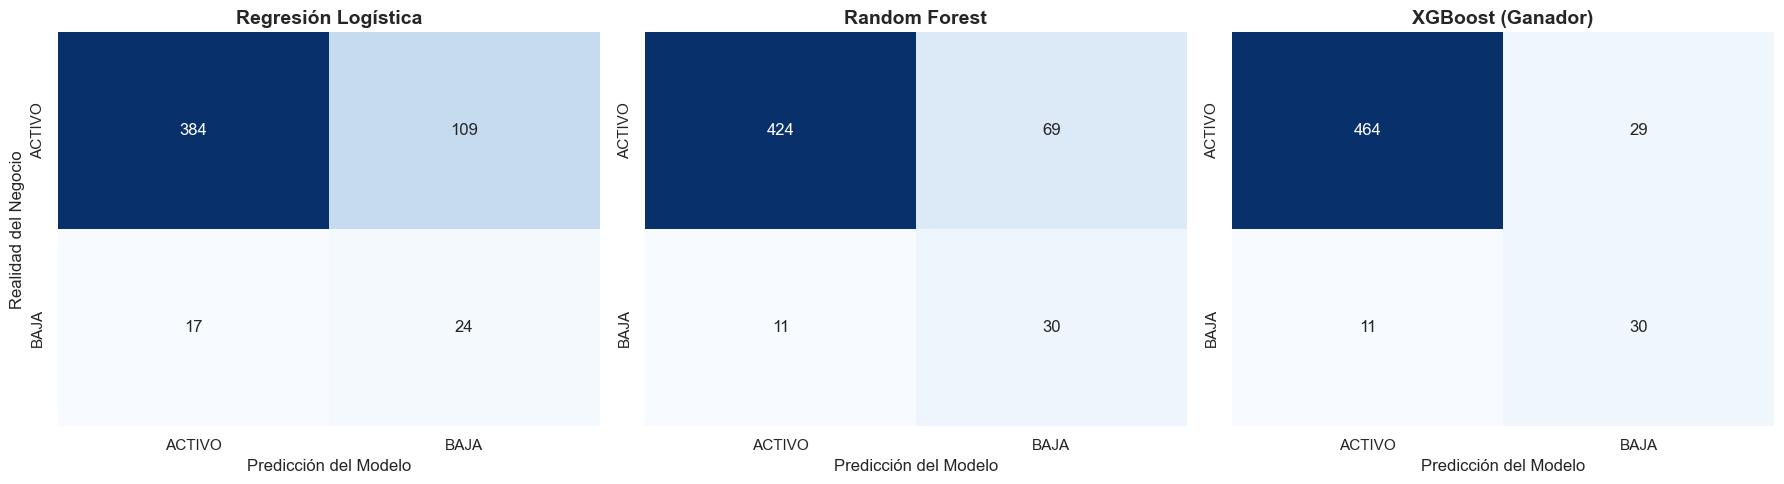


   2/3 Generando Curva ROC combinada...


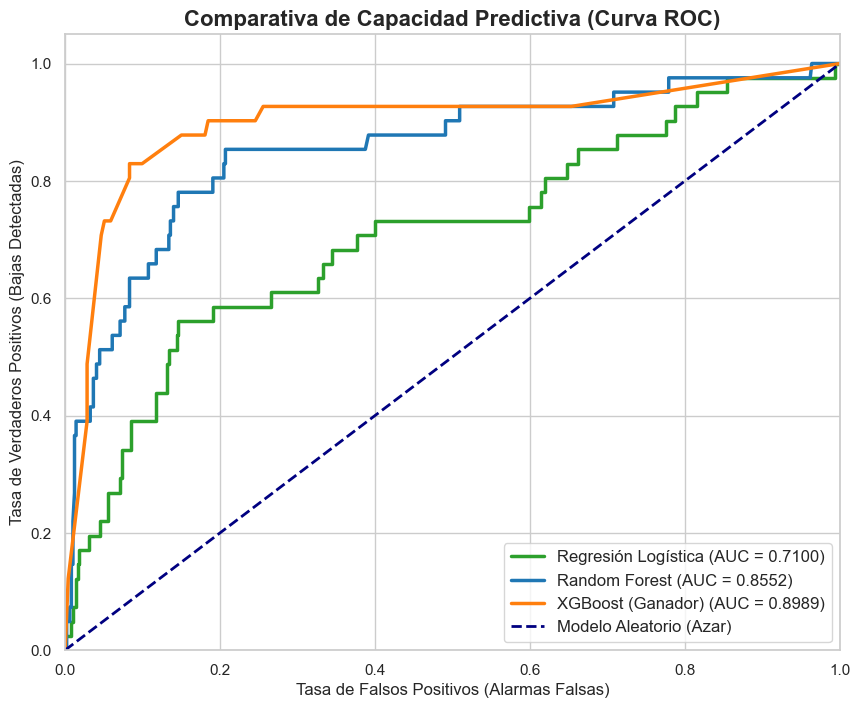


   3/3 Generando explicación SHAP para el ganador (XGBoost)...


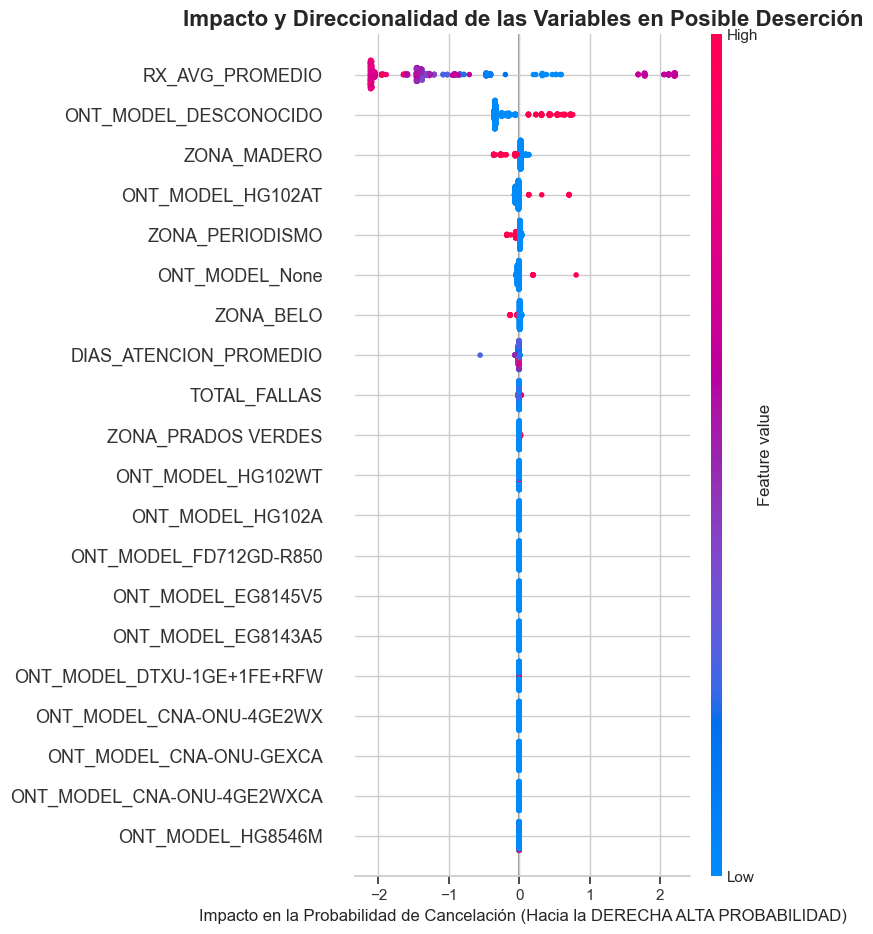


[EXITO] Las 3 imágenes se mostraron en pantalla y están guardadas en la carpeta 'graficos_modelado'.


In [10]:
import matplotlib.pyplot as plt #Importar librería pyplot
import seaborn as sns #Importar librería seaborn
from sklearn.metrics import confusion_matrix, roc_curve, auc #Importar métricas
import shap #Importar librería explicabilidad
import os #Importar módulo sistema
from sklearn.preprocessing import StandardScaler #Importar escalador

def generar_visualizaciones_directivas(X_test, y_test, mod_rf, mod_xgb, mod_lr): #Definir función principal
    print("Iniciando generación de gráficos ejecutivos de alto impacto...") #Imprimir inicio
    
    ruta_salida = "graficos_modelado" #Definir nombre carpeta
    if not os.path.exists(ruta_salida): #Verificar existencia
        os.makedirs(ruta_salida) #Crear carpeta
        
    sns.set_theme(style="whitegrid") #Establecer estilo visual
    
    #Preparar datos escalados estrictamente para Regresión Logística
    scaler = StandardScaler() #Instanciar escalador
    X_test_s = scaler.fit_transform(X_test) #Escalar datos prueba
    
    print("\n   1/3 Generando comparativa de Matrices de Confusión...") #Imprimir progreso
    fig, axes = plt.subplots(1, 3, figsize=(18, 5)) #Crear lienzo triple
    
    modelos = [mod_lr, mod_rf, mod_xgb] #Listar modelos evaluados
    nombres = ['Regresión Logística', 'Random Forest', 'XGBoost (Ganador)'] #Listar nombres presentacion
    datos_x = [X_test_s, X_test, X_test] #Asignar datos correspondientes
    
    for i, (modelo, nombre, x_dat) in enumerate(zip(modelos, nombres, datos_x)): #Iterar modelos
        y_pred = modelo.predict(x_dat) #Predecir etiquetas
        cm = confusion_matrix(y_test, y_pred) #Calcular matriz
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[i],
                    xticklabels=['ACTIVO', 'BAJA'], yticklabels=['ACTIVO', 'BAJA']) #Dibujar mapa calor
        axes[i].set_title(f'{nombre}', fontsize=14, fontweight='bold') #Añadir titulo subgrafico
        axes[i].set_xlabel('Predicción del Modelo') #Añadir etiqueta X
        if i == 0: #Condicion primer grafico
            axes[i].set_ylabel('Realidad del Negocio') #Añadir etiqueta Y
        
    plt.tight_layout() #Ajustar margenes
    plt.savefig(f"{ruta_salida}/01_matrices_confusion_comparativa.png", bbox_inches='tight', dpi=300) #Guardar grafico
    plt.show() #Mostrar figura consola
    
    print("\n   2/3 Generando Curva ROC combinada...") #Imprimir progreso
    plt.figure(figsize=(10, 8)) #Configurar tamaño
    
    colores = ['#2ca02c', '#1f77b4', '#ff7f0e'] #Definir colores institucionales
    for modelo, nombre, x_dat, color in zip(modelos, nombres, datos_x, colores): #Iterar modelos
        y_prob = modelo.predict_proba(x_dat)[:, 1] #Extraer probabilidades
        fpr, tpr, _ = roc_curve(y_test, y_prob) #Calcular tasas
        roc_auc = auc(fpr, tpr) #Calcular area
        plt.plot(fpr, tpr, color=color, lw=2.5, label=f'{nombre} (AUC = {roc_auc:.4f})') #Dibujar curva
        
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Modelo Aleatorio (Azar)') #Dibujar linea base
    plt.xlim([0.0, 1.0]) #Limitar eje X
    plt.ylim([0.0, 1.05]) #Limitar eje Y
    plt.xlabel('Tasa de Falsos Positivos (Alarmas Falsas)', fontsize=12) #Añadir etiqueta X
    plt.ylabel('Tasa de Verdaderos Positivos (Bajas Detectadas)', fontsize=12) #Añadir etiqueta Y
    plt.title('Comparativa de Capacidad Predictiva (Curva ROC)', fontsize=16, fontweight='bold') #Añadir titulo
    plt.legend(loc="lower right", fontsize=12) #Mostrar leyenda
    plt.savefig(f"{ruta_salida}/02_curva_roc_combinada.png", bbox_inches='tight', dpi=300) #Guardar grafico
    plt.show() #Mostrar figura consola
    
    print("\n   3/3 Generando explicación SHAP para el ganador (XGBoost)...") #Imprimir progreso
    
    #Configurar motor SHAP
    explainer = shap.TreeExplainer(mod_xgb) #Instanciar explicador arboles
    shap_values = explainer.shap_values(X_test) #Calcular valores shap
    
    #Generar grafico
    plt.figure(figsize=(12, 8)) #Configurar tamaño
    shap.summary_plot(shap_values, X_test, show=False) #Generar grafico puntos
    plt.xlabel("Impacto en la Probabilidad de Cancelación (Hacia la DERECHA ALTA PROBABILIDAD)", fontsize=12) # Definir nuevo texto
    plt.title('Impacto y Direccionalidad de las Variables en Posible Deserción', fontsize=16, fontweight='bold') #Añadir titulo
    plt.tight_layout() #Ajustar margenes
    plt.savefig(f"{ruta_salida}/03_shap_xgboost.png", bbox_inches='tight', dpi=300) #Guardar grafico
    plt.show() #Mostrar figura consola
    
    print(f"\n[EXITO] Las 3 imágenes se mostraron en pantalla y están guardadas en la carpeta '{ruta_salida}'.") #Imprimir confirmacion

if __name__ == "__main__": #Verificar ejecucion principal
    #Inyectamos los datos y los 3 modelos ya entrenados en memoria
    generar_visualizaciones_directivas(X_prueba, y_prueba, modelo_rf, modelo_xgb, modelo_lr) #Llamar funcion